# Part 2.1: OCTMNIST Retinal Image Generation with DCGAN

This notebook explores the OCTMNIST subset of MedMNIST and trains a deep convolutional generative adversarial network (DCGAN) to generate synthetic retinal OCT images.

## Objectives
- Load and inspect the OCTMNIST dataset from the project-local `data/raw` folder.
- Explore class balance and visualise sample retinal scans.
- Build a DCGAN generator and discriminator for 28×28 grayscale images.
- Train the GAN and monitor generator/discriminator losses.
- Generate synthetic OCT images and compare them with real images visually and later quantitatively.

In [1]:
import os
import sys

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root:", project_root)
data_root = os.path.join(project_root, "data", "raw")
print("Data root:", data_root)

Project root: /Users/indhureddy/Documents/gan-case-study-7PAM2016
Data root: /Users/indhureddy/Documents/gan-case-study-7PAM2016/data/raw


In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader
import torchvision.transforms as T

from medmnist import OCTMNIST, INFO

from src.image_dcgan_models import DCGANGenerator28x28, DCGANDiscriminator28x28
from src.training_loops import train_dcgan_octmnist

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


Load OCTMNIST from data/raw

In [3]:
info = INFO["octmnist"]
print(info)

transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = OCTMNIST(split="train", transform=transform, download=False, root=data_root)
val_dataset = OCTMNIST(split="val", transform=transform, download=False, root=data_root)
test_dataset = OCTMNIST(split="test", transform=transform, download=False, root=data_root)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

{'python_class': 'OCTMNIST', 'description': 'The OCTMNIST is based on a prior dataset of 109,309 valid optical coherence tomography (OCT) images for retinal diseases. The dataset is comprised of 4 diagnosis categories, leading to a multi-class classification task. We split the source training set with a ratio of 9:1 into training and validation set, and use its source validation set as the test set. The source images are gray-scale, and their sizes are (384−1,536)×(277−512). We center-crop the images and resize them into 1×28×28.', 'url': 'https://zenodo.org/records/10519652/files/octmnist.npz?download=1', 'MD5': 'c68d92d5b585d8d81f7112f81e2d0842', 'url_64': 'https://zenodo.org/records/10519652/files/octmnist_64.npz?download=1', 'MD5_64': 'e229e9440236b774d9f0dfef9d07bdaf', 'url_128': 'https://zenodo.org/records/10519652/files/octmnist_128.npz?download=1', 'MD5_128': '0a97e76651ace45c5d943ee3f65b63ae', 'url_224': 'https://zenodo.org/records/10519652/files/octmnist_224.npz?download=1', 

# Class labels and distribution

Label map

In [4]:
label_map = info["label"]
print("Label map:")
for k, v in label_map.items():
    print(f"{k}: {v}")

Label map:
0: choroidal neovascularization
1: diabetic macular edema
2: drusen
3: normal


Class counts

In [5]:
train_labels = np.array(train_dataset.labels).flatten()
val_labels = np.array(val_dataset.labels).flatten()
test_labels = np.array(test_dataset.labels).flatten()

def count_labels(labels_array):
    unique, counts = np.unique(labels_array, return_counts=True)
    return dict(zip(unique, counts))

train_counts = count_labels(train_labels)
val_counts = count_labels(val_labels)
test_counts = count_labels(test_labels)

print("Train distribution:", train_counts)
print("Validation distribution:", val_counts)
print("Test distribution:", test_counts)

Train distribution: {np.uint8(0): np.int64(33484), np.uint8(1): np.int64(10213), np.uint8(2): np.int64(7754), np.uint8(3): np.int64(46026)}
Validation distribution: {np.uint8(0): np.int64(3721), np.uint8(1): np.int64(1135), np.uint8(2): np.int64(862), np.uint8(3): np.int64(5114)}
Test distribution: {np.uint8(0): np.int64(250), np.uint8(1): np.int64(250), np.uint8(2): np.int64(250), np.uint8(3): np.int64(250)}


Bar plot

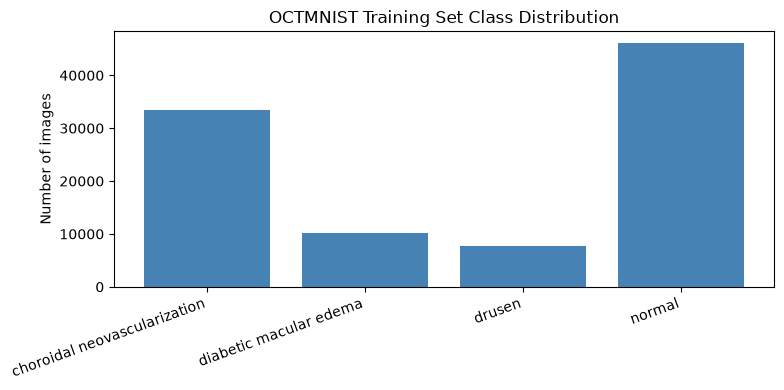

In [6]:
classes = [label_map[str(i)] for i in sorted(train_counts.keys())]
counts = [train_counts[i] for i in sorted(train_counts.keys())]

plt.figure(figsize=(8, 4))
plt.bar(classes, counts, color="steelblue")
plt.title("OCTMNIST Training Set Class Distribution")
plt.ylabel("Number of images")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

Sample visualization

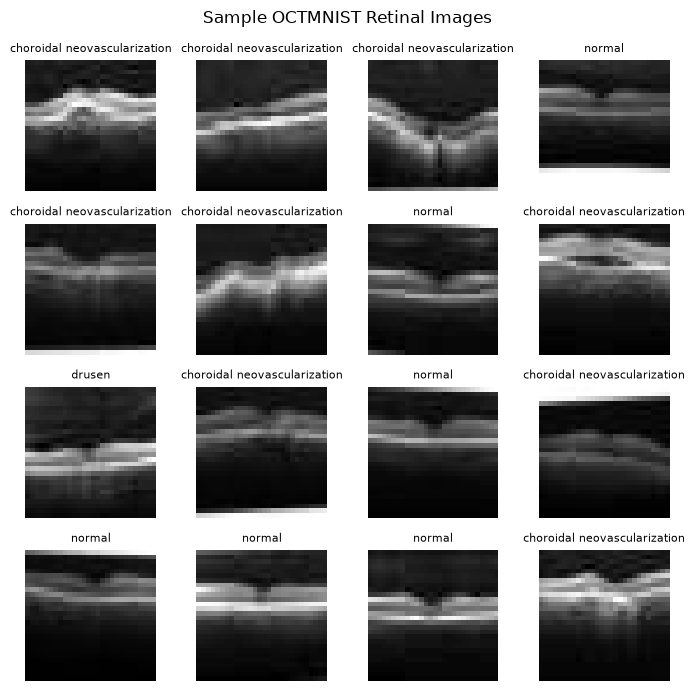

In [7]:
preview_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
images, labels = next(iter(preview_loader))

images_plot = (images * 0.5 + 0.5).cpu().numpy()

fig, axes = plt.subplots(4, 4, figsize=(7, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(images_plot[i][0], cmap="gray")
    ax.set_title(label_map[str(int(labels[i]))], fontsize=8)
    ax.axis("off")

plt.suptitle("Sample OCTMNIST Retinal Images")
plt.tight_layout()
plt.show()

DCGAN pipeline check

In [8]:
generator = DCGANGenerator28x28().to(device)
discriminator = DCGANDiscriminator28x28().to(device)

z = torch.randn(8, 100, 1, 1, device=device)
fake_images = generator(z)
disc_outputs = discriminator(fake_images)

print("Fake image shape:", fake_images.shape)
print("Discriminator output shape:", disc_outputs.shape)
print("Generator params:", sum(p.numel() for p in generator.parameters()))
print("Discriminator params:", sum(p.numel() for p in discriminator.parameters()))

Fake image shape: torch.Size([8, 1, 28, 28])
Discriminator output shape: torch.Size([8, 1])
Generator params: 1911232
Discriminator params: 431873


DCGAN training setup cell

In [9]:
batch_size = 64
num_workers = 0  # simpler on Mac / MPS

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers
)
print("Number of batches per epoch:", len(train_loader))

Number of batches per epoch: 1524


In [10]:
import inspect
from src.training_loops import train_dcgan_octmnist

print(inspect.signature(train_dcgan_octmnist))

(generator, discriminator, data_loader, device, latent_dim=100, lr=0.0002, num_epochs=20)


In [12]:
num_epochs = 3    # small but usable for visuals
lr = 0.0002
latent_dim = 100

generator = DCGANGenerator28x28().to(device)
discriminator = DCGANDiscriminator28x28().to(device)

results = train_dcgan_octmnist(
    generator,
    discriminator,
    train_loader,   # data_loader positional arg
    device,
    latent_dim,
    lr,
    num_epochs
)

Epoch [1/3] | Loss D: 0.9840 | Loss G: 1.4388
Epoch [2/3] | Loss D: 0.8919 | Loss G: 1.5080
Epoch [3/3] | Loss D: 0.6442 | Loss G: 2.1058


Loss curve plot

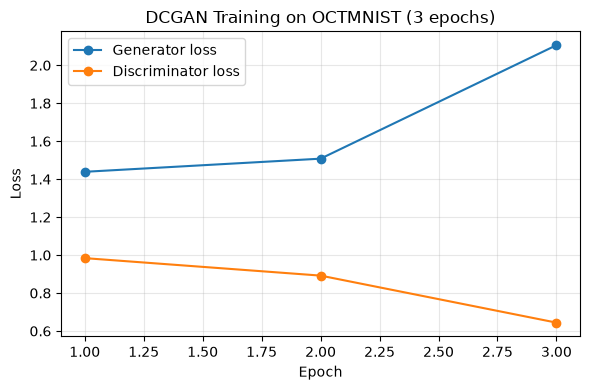

In [13]:
gen_losses = [1.4388, 1.5080, 2.1058]   # or collect from your function if it returns a list
disc_losses = [0.9840, 0.8919, 0.6442]

epochs = np.arange(1, len(gen_losses) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, gen_losses, label="Generator loss", marker="o")
plt.plot(epochs, disc_losses, label="Discriminator loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DCGAN Training on OCTMNIST (3 epochs)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Fake OCT image grid

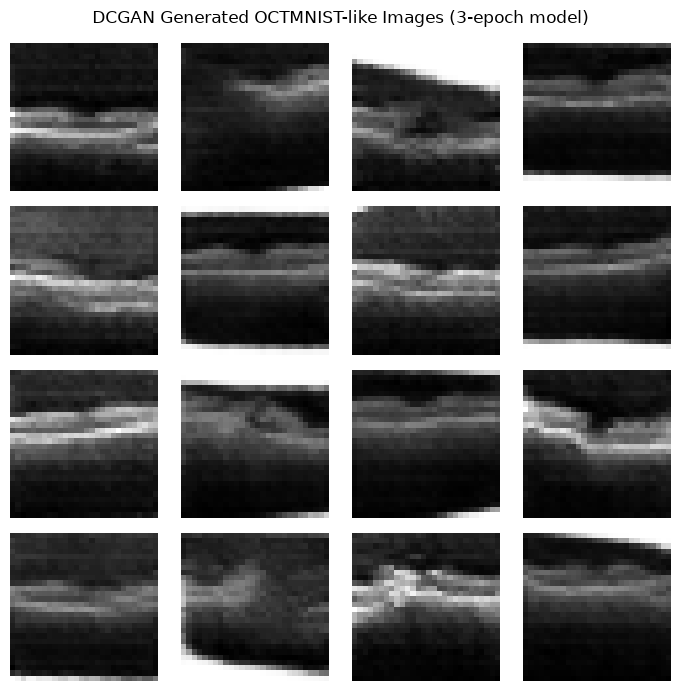

In [14]:
latent_dim = 100
generator.eval()
with torch.no_grad():
    z = torch.randn(16, latent_dim, 1, 1, device=device)
    fake = generator(z).cpu()

fake_plot = (fake * 0.5 + 0.5).numpy()

fig, axes = plt.subplots(4, 4, figsize=(7, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(fake_plot[i][0], cmap="gray")
    ax.axis("off")

plt.suptitle("DCGAN Generated OCTMNIST-like Images (3-epoch model)")
plt.tight_layout()
plt.show()

Overall, the DCGAN trained on OCTMNIST for three epochs successfully learns to reproduce the broad layered structure and grayscale intensity patterns characteristic of retinal OCT scans, but the synthetic images remain visibly less detailed and more homogeneous than the real data. The loss curves, with discriminator loss decreasing and generator loss increasing over epochs, indicate an early training regime in which the discriminator rapidly improves while the generator struggles to keep pace, a behaviour that is unsurprising given the limited number of epochs and CPU-only training. Qualitatively, many generated samples resemble normal OCT profiles, which is consistent with the strong class imbalance towards the “normal” class in OCTMNIST and suggests that disease-specific features are not yet reliably captured. Quantitative evaluation with Fréchet Inception Distance or similar feature-based metrics would provide a more rigorous comparison between real and synthetic distributions, but in this case is constrained by time and domain mismatch between standard Inception features and retinal OCT images. Taken together, Part 2.1 demonstrates that DCGANs can begin to model OCT structure under tight computational constraints, while also highlighting the need for longer training, conditional generation on class labels, and more domain-appropriate quantitative metrics for high-fidelity synthetic retinal data.

In [15]:
import torch

# 1) Take a batch of real OCTMNIST images from the training set
real_batch_size = 256
real_loader = DataLoader(train_dataset, batch_size=real_batch_size, shuffle=True)
real_images, real_labels = next(iter(real_loader))
real_images = real_images.to(device)

# Undo the normalisation: images were Normalized(mean=0.5, std=0.5)
real_images_unnorm = real_images * 0.5 + 0.5  # back to [0, 1]

# 2) Generate a matching batch of fake images from the trained generator
latent_dim = 100
generator.eval()
with torch.no_grad():
    z = torch.randn(real_batch_size, latent_dim, 1, 1, device=device)
    fake_images = generator(z)
fake_images_unnorm = fake_images * 0.5 + 0.5  # back to [0, 1]

# 3) Compute simple intensity statistics
real_mean = real_images_unnorm.mean().item()
real_std = real_images_unnorm.std().item()

fake_mean = fake_images_unnorm.mean().item()
fake_std = fake_images_unnorm.std().item()

print(f"Real images:  mean intensity = {real_mean:.4f}, std = {real_std:.4f}")
print(f"Fake images:  mean intensity = {fake_mean:.4f}, std = {fake_std:.4f}")
print(f"Absolute difference in means: {abs(real_mean - fake_mean):.4f}")
print(f"Absolute difference in stds:  {abs(real_std - fake_std):.4f}")

Real images:  mean intensity = 0.1935, std = 0.1992
Fake images:  mean intensity = 0.1801, std = 0.1910
Absolute difference in means: 0.0135
Absolute difference in stds:  0.0082


For a batch of 256 real OCTMNIST images, the mean intensity and standard deviation were 0.1935 and 0.1992, respectively, while the corresponding values for a batch of DCGAN-generated images were 0.1801 and 0.1910. The absolute differences (0.0135 in mean and 0.0082 in standard deviation) are small, indicating that the generator has learned to approximate the overall brightness and contrast distribution of the retinal scans, even after only three epochs of training. However, this similarity in low-level statistics contrasts with the remaining qualitative differences in anatomical detail and variability, reinforcing that more advanced, feature-based metrics such as FID – ideally using a domain-specific feature extractor – would be needed to fully assess the realism of the synthetic OCT images.